In [1]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, utils
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [2]:
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything()


In [3]:
class Encoder(nn.Module):
    def __init__(self, z_dim: int):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1),  # 64→32
            nn.ReLU(True),
            nn.Conv2d(32, 64, 4, 2, 1),  # 32→16
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.Conv2d(64, 128, 4, 2, 1),  # 16→8
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.Flatten(),
        )
        self.fc_mu = nn.Linear(128 * 8 * 8, z_dim)
        self.fc_logvar = nn.Linear(128 * 8 * 8, z_dim)

    def forward(self, x):
        h = self.conv(x)
        return self.fc_mu(h), self.fc_logvar(h)

class Decoder(nn.Module):
    def __init__(self, z_dim: int):
        super().__init__()
        self.fc = nn.Linear(z_dim, 128 * 8 * 8)
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1),  # 8→16
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),  # 16→32
            nn.BatchNorm2d(32),
            nn.ReLU(True),
            nn.ConvTranspose2d(32, 3, 4, 2, 1),   # 32→64
            nn.Sigmoid(),
        )

    def forward(self, z):
        h = self.fc(z).view(-1, 128, 8, 8)
        return self.deconv(h)

class VAE(nn.Module):
    def __init__(self, z_dim: int = 128):
        super().__init__()
        self.encoder = Encoder(z_dim)
        self.decoder = Decoder(z_dim)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decoder(z)
        return recon, mu, logvar

def vae_loss(recon_x, x, mu, logvar):
    recon_loss = nn.functional.binary_cross_entropy(recon_x, x, reduction='sum')
    kl_div = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl_div

In [4]:
def vae_loss(recon_x, x, mu, logvar):
    recon_loss = nn.functional.binary_cross_entropy(recon_x, x, reduction='sum')
    kl_div = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl_div

In [5]:
img_size = 64
batch_size = 64
data_root = r'C:\Users\Admin\Downloads\Comp_vision\data\processed\train'

transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
])

full_dataset = datasets.ImageFolder(data_root, transform=transform)

sample_size = 20000 
indices = torch.randperm(len(full_dataset))[:sample_size]
dataset = Subset(full_dataset, indices)

dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)


In [6]:
z_dim = 64
vae = VAE(z_dim=z_dim).to(device)

optimizer = optim.Adam(vae.parameters(), lr=1e-3)
epochs = 50

In [7]:
import time

epoch_times = []

for epoch in range(epochs):
    start_time = time.time()
    vae.train()
    running_loss = 0.0
    
    for x, _ in dataloader:
        x = x.to(device)
        optimizer.zero_grad()
        recon, mu, logvar = vae(x)
        loss = vae_loss(recon, x, mu, logvar)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    epoch_time = time.time() - start_time
    epoch_times.append(epoch_time)
    
    avg_epoch_time = sum(epoch_times) / len(epoch_times)
    epochs_left = epochs - (epoch + 1)
    est_total_time_left = avg_epoch_time * epochs_left
    
    # Convert seconds to minutes and seconds
    mins_left = int(est_total_time_left // 60)
    secs_left = int(est_total_time_left % 60)
    
    epoch_loss = running_loss / len(dataloader.dataset)
    print(f"Epoch {epoch+1}/{epochs} completed | Loss: {epoch_loss:.4f} | "
          f"Time: {epoch_time:.1f}s | "
          f"Estimated total training time left: {mins_left}m {secs_left}s")

Epoch 1/50 completed | Loss: 7372.6698 | Time: 27.8s | Estimated total training time left: 22m 44s
Epoch 2/50 completed | Loss: 7116.0830 | Time: 27.0s | Estimated total training time left: 21m 56s
Epoch 3/50 completed | Loss: 7100.4695 | Time: 26.7s | Estimated total training time left: 21m 16s
Epoch 4/50 completed | Loss: 7091.7772 | Time: 26.9s | Estimated total training time left: 20m 46s
Epoch 5/50 completed | Loss: 7085.6050 | Time: 27.0s | Estimated total training time left: 20m 18s
Epoch 6/50 completed | Loss: 7080.7992 | Time: 25.2s | Estimated total training time left: 19m 37s
Epoch 7/50 completed | Loss: 7077.7156 | Time: 17.6s | Estimated total training time left: 18m 14s
Epoch 8/50 completed | Loss: 7074.3474 | Time: 17.4s | Estimated total training time left: 17m 6s
Epoch 9/50 completed | Loss: 7072.3245 | Time: 17.4s | Estimated total training time left: 16m 10s
Epoch 10/50 completed | Loss: 7068.4066 | Time: 17.5s | Estimated total training time left: 15m 21s
Epoch 11/5

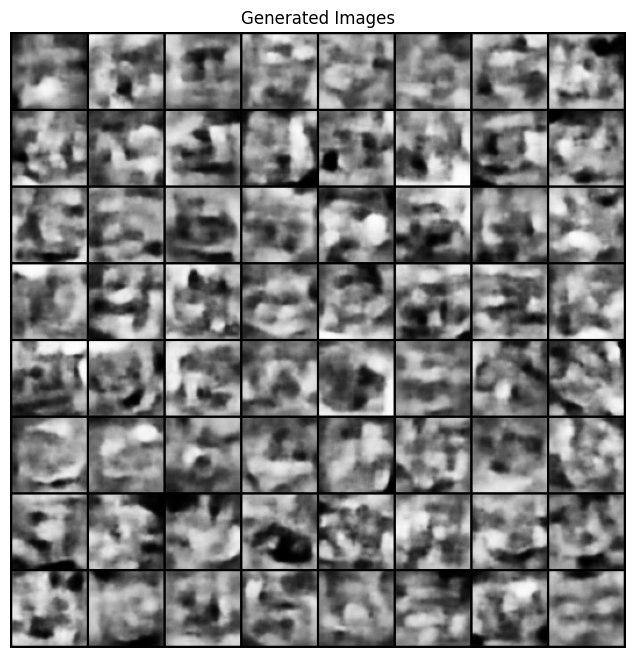

In [8]:
vae.eval()
with torch.no_grad():
    z = torch.randn(64, z_dim).to(device)
    samples = vae.decoder(z).cpu()

grid = utils.make_grid(samples, nrow=8)
plt.figure(figsize=(8, 8))
plt.axis('off')
plt.title('Generated Images')
plt.imshow(np.transpose(grid, (1, 2, 0)))
plt.show()

### Hyperparameter tuning

In [12]:
from itertools import product

search_space = {
    'z_dim': [32, 64, 128],
    'lr': [1e-3, 5e-4],
    'batch_size': [64, 128],
    'epochs': [5],
}

hyperparam_combinations = list(product(*search_space.values()))
param_names = list(search_space.keys())

print(f"Total configs to try: {len(hyperparam_combinations)}")


Total configs to try: 12


In [10]:
def train_vae_once(config, data_root='processed/train'):
    z_dim, lr, batch_size, epochs = config
    
    transform = transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.ToTensor(),
    ])
    
    full_dataset = datasets.ImageFolder(data_root, transform=transform)
    sample_size = 2000
    indices = torch.randperm(len(full_dataset))[:sample_size]
    dataset = Subset(full_dataset, indices)
    
    # Train/val split
    split = int(0.8 * len(dataset))
    train_set = Subset(dataset, list(range(split)))
    val_set = Subset(dataset, list(range(split, len(dataset))))
    
    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)
    
    vae = VAE(z_dim=z_dim).to(device)
    optimizer = optim.Adam(vae.parameters(), lr=lr)
    
    # Train loop
    for epoch in range(epochs):
        vae.train()
        for x, _ in train_loader:
            x = x.to(device)
            optimizer.zero_grad()
            recon, mu, logvar = vae(x)
            loss = vae_loss(recon, x, mu, logvar)
            loss.backward()
            optimizer.step()

    # Validation loss
    vae.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x, _ in val_loader:
            x = x.to(device)
            recon, mu, logvar = vae(x)
            loss = vae_loss(recon, x, mu, logvar)
            val_loss += loss.item()
    
    avg_val_loss = val_loss / len(val_loader.dataset)
    return avg_val_loss


In [11]:
best_config = None
best_loss = float('inf')
results = []

for combo in hyperparam_combinations:
    config_dict = dict(zip(param_names, combo))
    print(f"Testing config: {config_dict}")
    
    loss = train_vae_once(combo)
    results.append((combo, loss))
    
    if loss < best_loss:
        best_loss = loss
        best_config = combo
    
    print(f"Validation Loss: {loss:.4f}\n")

print("\nBest Configuration:")
print(dict(zip(param_names, best_config)))
print(f"Best Validation Loss: {best_loss:.4f}")


Testing config: {'z_dim': 32, 'lr': 0.001, 'batch_size': 64, 'epochs': 5}
Validation Loss: 7391.2267

Testing config: {'z_dim': 32, 'lr': 0.001, 'batch_size': 128, 'epochs': 5}
Validation Loss: 7482.7521

Testing config: {'z_dim': 32, 'lr': 0.0005, 'batch_size': 64, 'epochs': 5}
Validation Loss: 7400.5175

Testing config: {'z_dim': 32, 'lr': 0.0005, 'batch_size': 128, 'epochs': 5}
Validation Loss: 7577.1782

Testing config: {'z_dim': 64, 'lr': 0.001, 'batch_size': 64, 'epochs': 5}
Validation Loss: 7260.8731

Testing config: {'z_dim': 64, 'lr': 0.001, 'batch_size': 128, 'epochs': 5}
Validation Loss: 7555.8759

Testing config: {'z_dim': 64, 'lr': 0.0005, 'batch_size': 64, 'epochs': 5}
Validation Loss: 7313.1079

Testing config: {'z_dim': 64, 'lr': 0.0005, 'batch_size': 128, 'epochs': 5}
Validation Loss: 7466.9399

Testing config: {'z_dim': 128, 'lr': 0.001, 'batch_size': 64, 'epochs': 5}
Validation Loss: 7337.8022

Testing config: {'z_dim': 128, 'lr': 0.001, 'batch_size': 128, 'epochs': 